In [1]:
from supabase import create_client
from datetime import datetime, timezone
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


SUPABASE_URL     = os.environ["SUPABASE_URL"]
SUPABASE_KEY     = os.environ["SUPABASE_KEY"]
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

In [2]:
def select_supabase(table, columns="*", filters=None, batch_size=1000):
     all_rows = []
     start = 0

     while True:
         query = supabase.table(table).select(columns).range(start, start + batch_size - 1)

         if filters:
             for f in filters:
                 query = query.filter(*f)

         resp = query.execute()
         rows = resp.data or []

         if not rows:
             break

         all_rows.extend(rows)

         if len(rows) < batch_size:
             break

         start += batch_size

     return all_rows

all_rows = select_supabase("servo_prices", columns="*", filters=None, batch_size=1000)
dfprice = pd.DataFrame(all_rows)
print(dfprice.shape)
dfprice['updated_at'] = pd.to_datetime(dfprice['updated_at'])
dfprice['updated_at_dt'] = dfprice['updated_at'].dt.date
dfprice.head()

(488856, 7)


,id,station_id,fuel_type,is_available,price,updated_at,recorded_at,updated_at_dt
0,1,QTiwE7rYsh03w7hjFGzwruei1968jcn9iMPF4QmIQvw=,U91,True,189.9,2026-05-04 20:00:00+00:00,2026-05-07T02:53:42.384747+00:00,2026-05-04
1,2,QTiwE7rYsh03w7hjFGzwruei1968jcn9iMPF4QmIQvw=,P95,True,207.9,2026-05-04 20:00:00+00:00,2026-05-07T02:53:42.384747+00:00,2026-05-04
2,3,QTiwE7rYsh03w7hjFGzwruei1968jcn9iMPF4QmIQvw=,P98,True,211.9,2026-05-04 20:00:00+00:00,2026-05-07T02:53:42.384747+00:00,2026-05-04
3,4,QTiwE7rYsh03w7hjFGzwruei1968jcn9iMPF4QmIQvw=,DSL,True,255.9,2026-05-04 20:00:00+00:00,2026-05-07T02:53:42.384747+00:00,2026-05-04
4,5,QTiwE7rYsh03w7hjFGzwruei1968jcn9iMPF4QmIQvw=,LPG,True,109.9,2026-05-04 20:00:00+00:00,2026-05-07T02:53:42.384747+00:00,2026-05-04


In [3]:
df91 = dfprice.loc[dfprice['fuel_type']=='U91',:]
df91mean = pd.DataFrame(df91.groupby('updated_at_dt')['price'].median())
df91mean.index = df91mean.index.astype('datetime64[ns]')
df91mean['price_change_pct'] = df91mean['price'].pct_change() * 100
df91mean['price_change'] = df91mean['price_change_pct'].diff()
df91mean.head()

,price,price_change_pct,price_change
updated_at_dt,,,
2026-05-04,179.9,NaN,NaN
2026-05-05,179.9,0.000000,NaN
2026-05-06,179.9,0.000000,0.000000
2026-05-07,181.7,1.000556,1.000556
2026-05-08,181.9,0.110072,-0.890484


In [ ]:
all_rows = select_supabase("market_data", columns="*", filters=None, batch_size=1000)
dfmarket = pd.DataFrame(all_rows)
dfmarket = dfmarket.pivot(index='date', columns='metric', values='value').reset_index()
dfmarket['date'] = pd.to_datetime(dfmarket['date'])
# fillna with the previous value
dfmarket.sort_values('date', inplace=True)
dfmarket.ffill(inplace=True)
dfmarket.tail()

TypeError: NDFrame.fillna() got an unexpected keyword argument 'method'

In [9]:
type(dfmarket)

pandas.DataFrame

In [5]:
all_rows = select_supabase("servo_stations", columns="id, name, gcc_name21, sa4_name21", filters=None, batch_size=1000)
dfstations = pd.DataFrame(all_rows)
dfstations.head()

,id,name,gcc_name21,sa4_name21
0,g0kw39lPWAc72yD+7FVt7/5MPUkGxOIsjkvpB0J55q0=,Liberty Kerang,Rest of Vic.,North West
1,ewjNNW0HpnHEFMYweF2F2SPOU46lVL8cGeQN0/Z3aL0=,Shell Wodonga,Rest of Vic.,Hume
2,g6D76kTLASGmeMwg8NfkZcgGqcPJbD3OyKG8R5052v8=,Freshwater Creek General Store,Rest of Vic.,Geelong
3,6j0wtI9NxzyciLgnP01GMxHKOBGgnSDmWi85Ysyu0ns=,Redesdale General Store,Rest of Vic.,Bendigo
4,PAVCB1Mbpc+BbqOsC6ELU/PcXi03/RGesI1DnQwXZUA=,Yenda Producers,Rest of Vic.,Hume


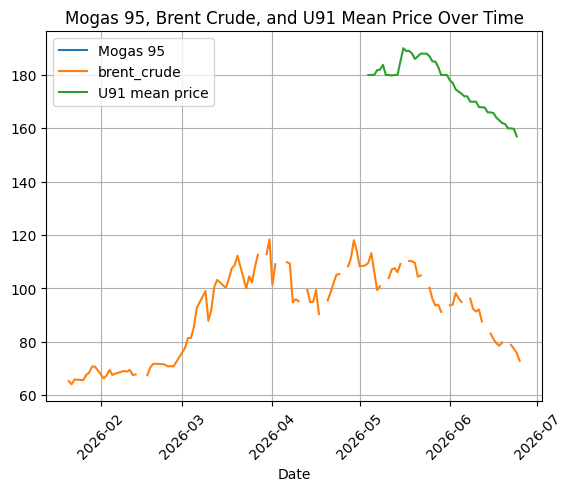

In [6]:
plt.plot(dfmarket.date, dfmarket['mogas_95'], label='Mogas 95')
plt.plot(dfmarket.date, dfmarket['brent_crude'], label='brent_crude')
plt.plot(df91mean.index, df91mean['price'], label='U91 mean price')
plt.grid()
plt.legend()
plt.title('Mogas 95, Brent Crude, and U91 Mean Price Over Time')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df91 = df91mean.merge(dfmarket, left_on='updated_at_dt', right_on='date', how='outer')


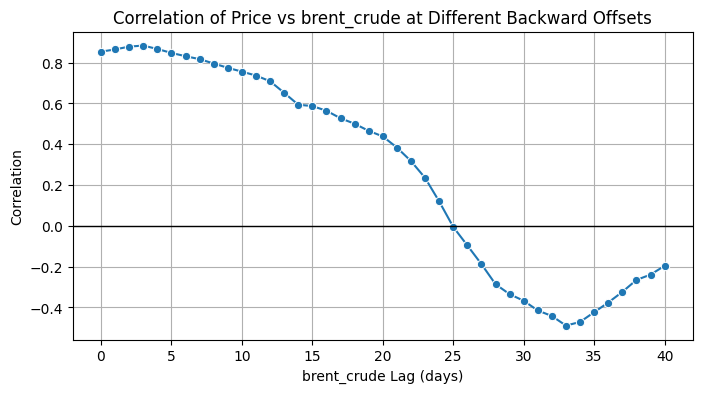

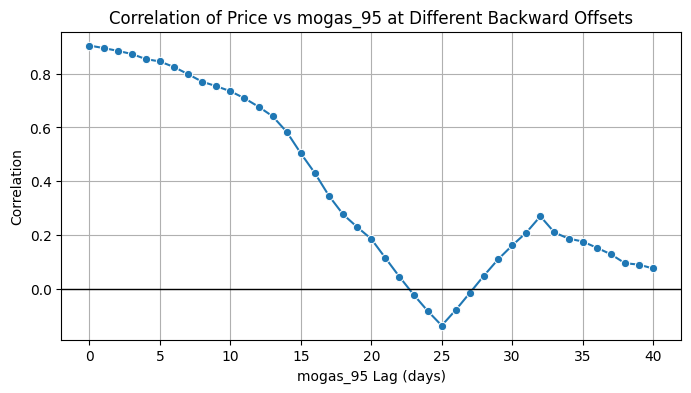

In [ ]:
# correlation between today's brent_crude and future price values
corr_rows = []

servo_rows = df91.loc[df91['price'].notna()].shape[0]

def correl_metric(df, metric, laglen):

    tmp = df[['date', 'price', metric]].sort_values('date').copy()
    for lag in range(0, laglen+1):
        shifted = tmp.copy()
        shifted[f'{metric}_lag'] = shifted[metric].shift(lag)

        corr = shifted[['price', f'{metric}_lag']].dropna().corr().iloc[0, 1]
        corr_rows.append({f'{metric}_lag': lag, 'correlation': corr})

    corr_df = pd.DataFrame(corr_rows)
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=corr_df, x=f'{metric}_lag', y='correlation', marker='o')
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f'Correlation of Price vs {metric} at Different Backward Offsets')
    plt.xlabel(f'{metric} Lag (days)')
    plt.ylabel('Correlation')
    plt.grid(True)
    plt.show()
    
correl_metric(df91, "brent_crude", 40)
correl_metric(df91, "mogas_95", 40)

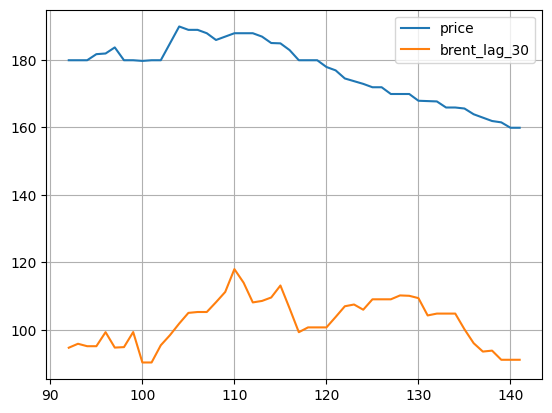

In [ ]:
temp = df91.copy()#df91.loc[df91['price'].notna()].copy()
temp['brent_lag_30'] = temp['brent_crude'].shift(22)
temp.loc[temp['price'].notna(), ['price', 'brent_lag_30']].plot()
plt.grid()


In [ ]:
dfprice_geo = dfprice.merge(dfstations, left_on='station_id', right_on='id', how='left')


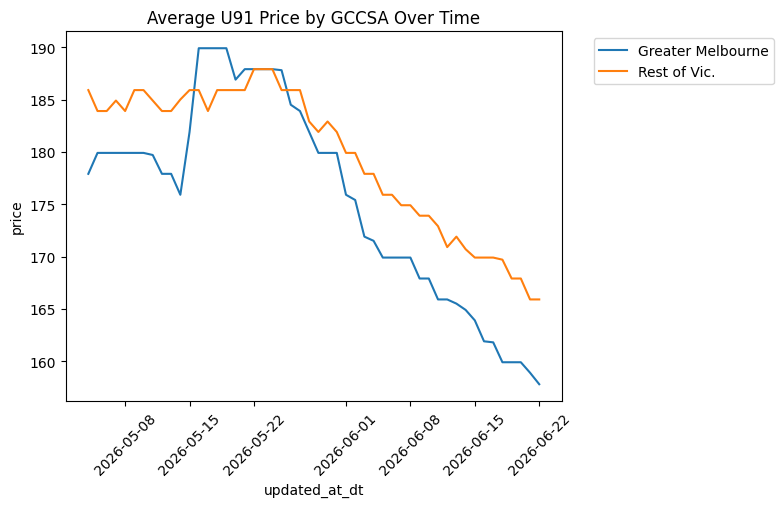

In [ ]:
temp = dfprice_geo.loc[dfprice_geo['fuel_type']=='U91',:].groupby(['gcc_name21','updated_at_dt'])['price'].median()

sns.lineplot(data=temp.reset_index(), x='updated_at_dt', y='price', hue='gcc_name21')
plt.title('Average U91 Price by GCCSA Over Time')
# Legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

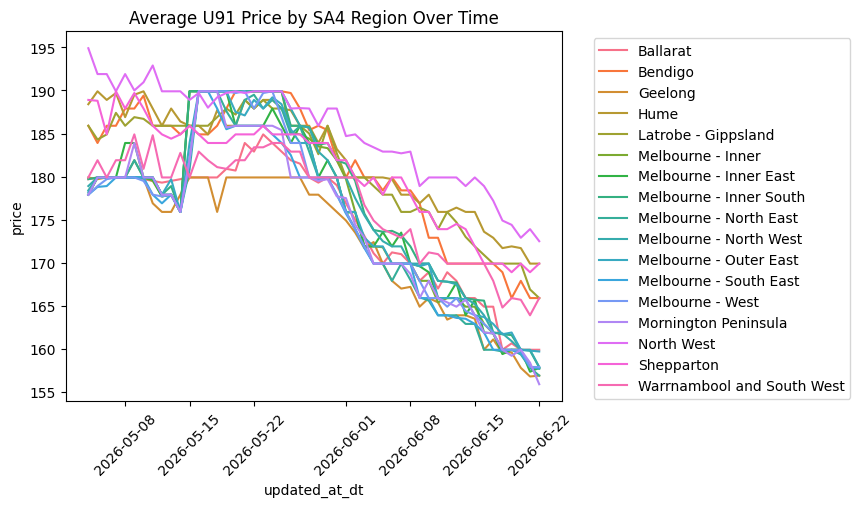

In [ ]:
temp = dfprice_geo.loc[dfprice_geo['fuel_type']=='U91',:].groupby(['sa4_name21','updated_at_dt'])['price'].median()

sns.lineplot(data=temp.reset_index(), x='updated_at_dt', y='price', hue='sa4_name21')
plt.title('Average U91 Price by SA4 Region Over Time')
# Legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#df91['Weekday'] = df91.loc[df91['price'].notna(), 'date'].dt.weekday
df91['Weekday'] = df91['date'].dt.weekday
df91['WeekNumber'] = df91['date'].dt.isocalendar().week

TypeError: Cannot interpret 'UInt32Dtype()' as a data type

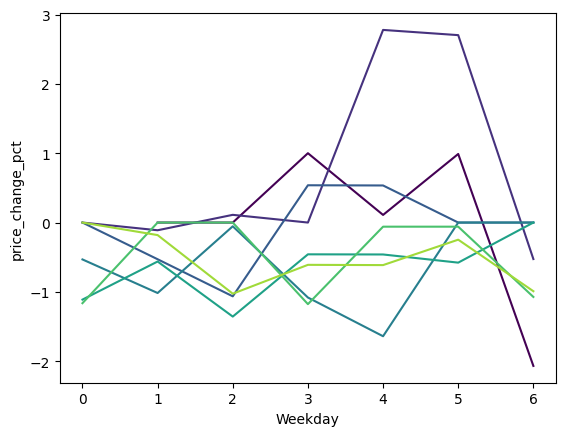

In [ ]:
sns.lineplot(data=df91.loc[df91['price_change_pct'].notna()], x='Weekday', y='price_change_pct', hue='WeekNumber', palette='viridis')
plt.grid()

In [ ]:
df91.head()

,price,price_change_pct,price_change,date,brent_crude,dxy,mogas_95,usd_aud,Weekday,WeekNumber
0,NaN,NaN,NaN,2026-01-02,NaN,NaN,NaN,1.4974,4,1
1,NaN,NaN,NaN,2026-01-05,NaN,NaN,NaN,1.4961,0,2
2,NaN,NaN,NaN,2026-01-06,NaN,NaN,NaN,1.4896,1,2
3,NaN,NaN,NaN,2026-01-07,NaN,NaN,NaN,1.4843,2,2
4,NaN,NaN,NaN,2026-01-08,NaN,NaN,NaN,1.4876,3,2


<Axes: xlabel='date', ylabel='brent_change'>

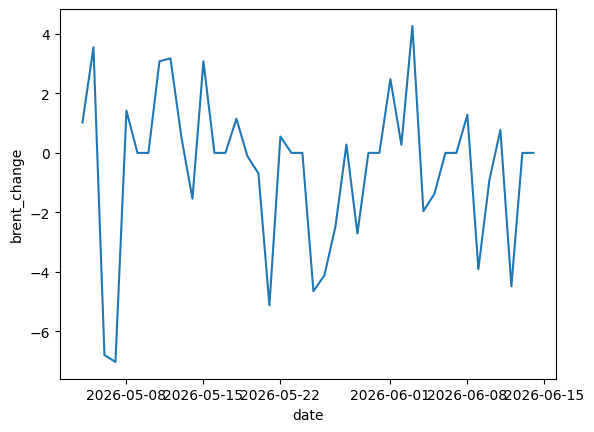

In [ ]:
temp=df91.copy()

temp['brent_crude_lag22'] = temp['brent_crude'].shift(22)
temp['brent_change'] = temp['brent_crude'].diff()
sns.lineplot(temp.loc[temp['price'].notna()], x='date',y='brent_change')


In [ ]:
temp

,price,price_change_pct,price_change,date,brent_crude,dxy,mogas_95,usd_aud,Weekday,WeekNumber,brent_crude_lag22,brent_change
0,NaN,NaN,NaN,2026-01-02,NaN,NaN,NaN,1.4974,4,1,NaN,NaN
1,NaN,NaN,NaN,2026-01-05,NaN,NaN,NaN,1.4961,0,2,NaN,NaN
2,NaN,NaN,NaN,2026-01-06,NaN,NaN,NaN,1.4896,1,2,NaN,NaN
3,NaN,NaN,NaN,2026-01-07,NaN,NaN,NaN,1.4843,2,2,NaN,NaN
4,NaN,NaN,NaN,2026-01-08,NaN,NaN,NaN,1.4876,3,2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
130,167.9,-1.177163,-1.177163,2026-06-11,92.08,100.124,103.2,1.4289,3,24,109.44,0.77
131,167.8,-0.059559,1.117604,2026-06-12,87.59,99.757,105.3,1.4193,4,24,104.31,-4.49
132,167.7,-0.059595,-0.000035,2026-06-13,87.59,99.757,105.3,1.4187,5,24,104.86,0.00
133,165.9,-1.073345,-1.013751,2026-06-14,87.59,99.757,105.3,1.4187,6,24,104.86,0.00


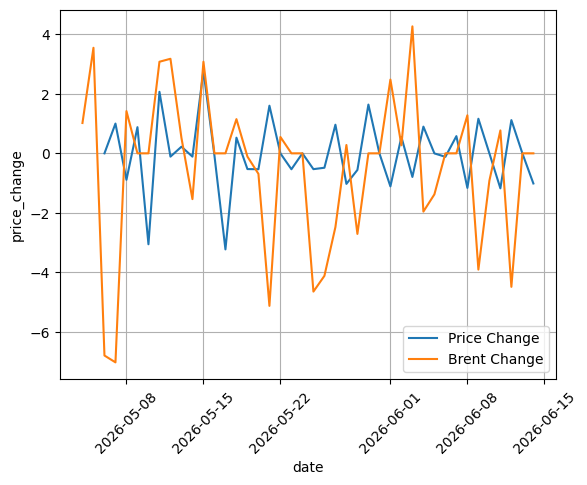

In [ ]:
sns.lineplot(data = df91.loc[temp['price'].notna()], x='date',y='price_change', label='Price Change')
sns.lineplot(temp.loc[temp['price'].notna()], x='date',y='brent_change', label='Brent Change')
plt.grid()
plt.xticks(rotation=45)
plt.show()

In [ ]:
check = temp.iloc[-25:,:].copy()
check['Forcast'] = 0
check.iloc[0]['Forcast'] = check.iloc[0]['price']
check


C:\Users\cutajara\AppData\Local\Temp\ipykernel_1016\2339493811.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  check.iloc[0]['Forcast'] = check.iloc[0]['price']


,price,price_change_pct,price_change,date,brent_crude,dxy,mogas_95,usd_aud,Weekday,WeekNumber,brent_crude_lag22,brent_change,Forcast
110,187.9,0.535045,-0.002878,2026-05-22,104.86,99.321,119.4,1.4023,4,21,118.03,0.55,0
111,187.9,0.000000,-0.535045,2026-05-23,104.86,99.321,119.4,1.4026,5,21,114.01,0.00,0
112,187.9,0.000000,0.000000,2026-05-24,104.86,99.321,119.4,1.4026,6,21,108.17,0.00,0
113,186.9,-0.532198,-0.532198,2026-05-25,100.21,98.998,119.4,1.3947,0,22,108.61,-4.65,0
114,185.0,-1.016586,-0.484388,2026-05-26,96.09,99.052,119.4,1.3955,1,22,109.63,-4.12,0
115,184.9,-0.054054,0.962532,2026-05-27,93.61,99.075,119.4,1.3996,2,22,113.18,-2.48,0
116,182.9,-1.081666,-1.027612,2026-05-28,93.89,99.346,119.4,1.4042,3,22,106.38,0.28,0
117,179.9,-1.640241,-0.558575,2026-05-29,91.18,99.115,106.4,1.3970,4,22,99.35,-2.71,0
118,179.9,0.000000,1.640241,2026-05-30,91.18,99.115,106.4,1.3916,5,22,100.77,0.00,0
119,179.9,0.000000,0.000000,2026-05-31,91.18,99.115,106.4,1.3916,6,22,100.77,0.00,0


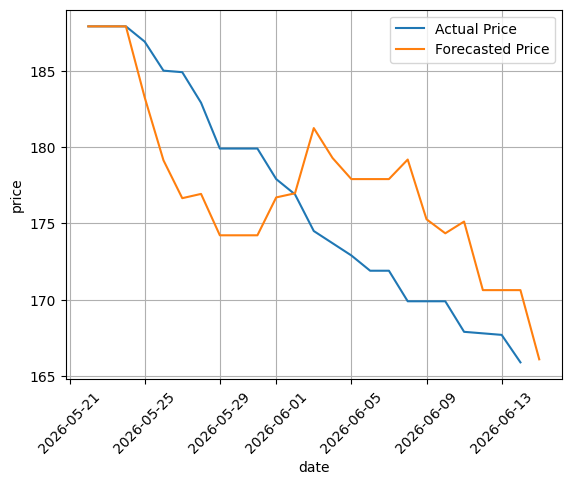

In [ ]:
startprice = check.iloc[0]['price']
forecast = []
for i , row in check.iterrows():
    if len(forecast) == 0:
        forecast.append(startprice)
        continue
    forecast.append(forecast[-1] + row['brent_change'])
    
check['Forcast'] = forecast

sns.lineplot(data = check, x='date',y='price', label='Actual Price')
sns.lineplot(data = check, x='date',y='Forcast', label='Forecasted Price')
plt.grid()
plt.xticks(rotation=45)
plt.show()

In [ ]:
check.iloc[-2]['price']

np.float64(165.9)

In [ ]:
check.iloc[-22:]['brent_change']

113   -4.65
114   -4.12
115   -2.48
116    0.28
117   -2.71
118    0.00
119    0.00
120    2.48
121    0.27
122    4.27
123   -1.96
124   -1.38
125    0.00
126    0.00
127    1.28
128   -3.91
129   -0.92
130    0.77
131   -4.49
132    0.00
133    0.00
134   -4.53
Name: brent_change, dtype: float64

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Use rows where target and predictors are available

df91['brent_crude_lag_22'] = df91['brent_crude'].shift(22)


model_df = df91[['price', 'brent_crude_lag_22', 'Weekday', 'WeekNumber']].dropna().copy()

X = model_df[['brent_crude_lag_22', 'Weekday', 'WeekNumber']]
y = model_df['price']

lr_model = LinearRegression()
lr_model.fit(X, y)

model_df['price_pred'] = lr_model.predict(X)

print(f"Rows used: {len(model_df)}")
print(f"Intercept: {lr_model.intercept_:.4f}")
print("Coefficients:")
print(pd.Series(lr_model.coef_, index=X.columns))

print(f"R²: {r2_score(y, model_df['price_pred']):.4f}")

model_df[['price', 'price_pred']].head()

Rows used: 42
Intercept: 203.9642
Coefficients:
brent_crude_lag_22    0.644462
Weekday              -0.278324
WeekNumber           -4.205643
dtype: float64
R²: 0.7020


,price,price_pred
92,179.9,185.119722
93,179.9,185.595419
94,179.9,184.853082
95,181.7,184.574759
96,181.9,186.977396


In [ ]:

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prepare time series: use df91 which has price and brent_crude aligned by date
arima_df = df91[['date', 'price', 'brent_crude']].dropna(subset=['date']).sort_values('date').copy()

# Create 21-day lagged brent_crude as exogenous variable
arima_df['brent_lag_21'] = arima_df['brent_crude'].shift(21)

# Drop rows missing either target or exogenous
arima_df = arima_df.dropna(subset=['price', 'brent_lag_21']).set_index('date')
arima_df.index.freq = 'D'

endog = arima_df['price']
exog  = arima_df[['brent_lag_21']]

print(f"Observations available: {len(arima_df)}")

# ARIMAX(1,1,1) — simpler order suited to limited data
model = SARIMAX(endog, exog=exog, order=(1, 1, 1), trend='c')
result = model.fit(disp=False)

print(result.summary())


Observations available: 42
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                   42
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 -78.389
Date:                Tue, 16 Jun 2026   AIC                            166.778
Time:                        16:46:38   BIC                            175.346
Sample:                    05-04-2026   HQIC                           169.898
                         - 06-14-2026                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept       -0.2419      0.416     -0.581      0.561      -1.058       0.574
brent_lag_21     0.0030      0.092      0.032      0.974      -0.178       0.184
ar.L1            

Observations: 41  (1 dropped for differencing initialisation)
MAE:  1.1672
RMSE: 1.6362
R²:   0.9436


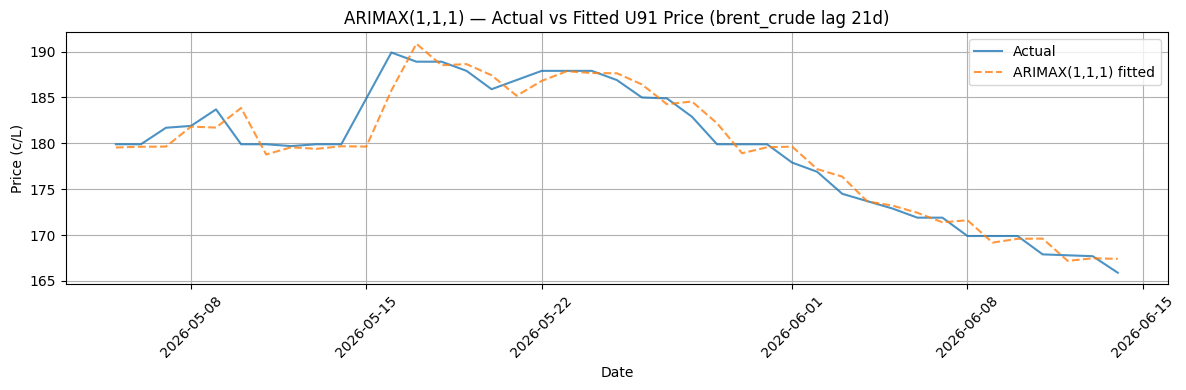

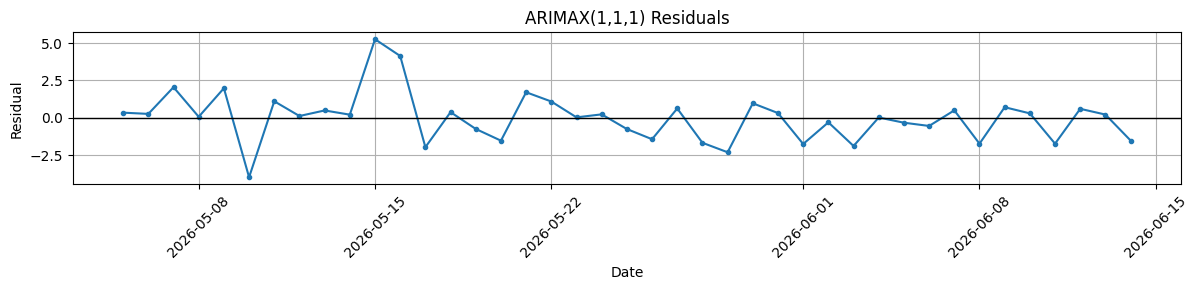

In [ ]:

# In-sample fitted values and metrics — skip first point (ARIMA d=1 initialisation artifact)
fitted = result.fittedvalues.iloc[1:]
actual = arima_df['price'].iloc[1:]

mae  = mean_absolute_error(actual, fitted)
rmse = np.sqrt(mean_squared_error(actual, fitted))
ss_res = ((actual - fitted) ** 2).sum()
ss_tot = ((actual - actual.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot

print(f"Observations: {len(actual)}  (1 dropped for differencing initialisation)")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

plt.figure(figsize=(12, 4))
plt.plot(actual.index, actual, label='Actual', alpha=0.8)
plt.plot(fitted.index, fitted, label='ARIMAX(1,1,1) fitted', linestyle='--', alpha=0.8)
plt.title('ARIMAX(1,1,1) — Actual vs Fitted U91 Price (brent_crude lag 21d)')
plt.xlabel('Date')
plt.ylabel('Price (c/L)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Residual plot
resid = result.resid.iloc[1:]
plt.figure(figsize=(12, 3))
plt.plot(resid.index, resid, marker='o', markersize=3)
plt.axhline(0, color='black', linewidth=1)
plt.title('ARIMAX(1,1,1) Residuals')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
